In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import LSTM, Dense
import logging
tf.get_logger().setLevel(logging.ERROR)

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

import time

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches  

np.random.seed(34)

In [4]:
%store -r FD1_X_Train
%store -r FD1_X_Test

%store -r FD1_X_Train_sc
%store -r FD1_X_Test_sc

%store -r FD1_y_Train
%store -r FD1_y_Test

%store -r FD1_Train
%store -r FD1_Test


FD1_X_Train_array = FD1_X_Train.values
FD1_X_Test_array = FD1_X_Test.values
FD1_y_Train_array = FD1_y_Train.values
FD1_y_Test_array = FD1_y_Test.values

X_train, X_val, y_train, y_val = train_test_split(FD1_X_Train, FD1_y_Train, test_size=0.2, random_state=42)

print("Training set - X:", X_train.shape, " y:", y_train.shape)
print("Validation set - X:", X_val.shape, " y:", y_val.shape)

Training set - X: (16504, 15)  y: (16504,)
Validation set - X: (4127, 15)  y: (4127,)


### Long-Short Term Memory

In [5]:
def create_lstm_model(input_shape):
    model = Sequential([
        layers.Reshape((input_shape[0], 1), input_shape=input_shape),
        layers.LSTM(128, activation="relu", return_sequences=True),
        layers.LSTM(64, activation="relu", return_sequences=True),
        layers.LSTM(32, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(loss="mse", optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))
    return model

In [6]:
def scheduler(epoch):
    if epoch < 5:
        return 0.001
    else:
        return 0.0001

callback = tf.keras.callbacks.LearningRateScheduler(scheduler, verbose = 1)

FD1_X_Train_array = FD1_X_Train.values
FD1_X_Test_array = FD1_X_Test.values

input_shape = FD1_X_Train_array.shape[1:]

lstm_model = create_lstm_model(input_shape)

lstm_model.compile(loss='mse', optimizer='adam')

FD1_y_Train_array = FD1_y_Train_array.astype('float32')
FD1_y_Test_array = FD1_y_Test_array.astype('float32')

history = lstm_model.fit(FD1_X_Train_array, FD1_y_Train_array, epochs=10, batch_size=128, callbacks=callback, validation_data=(FD1_X_Test_array, FD1_y_Test_array))


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/10


2024-04-19 12:22:09.086182: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-04-19 12:22:09.208271: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 4274.9189 - val_loss: 1973.9159 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1658.5037 - val_loss: 1332.3673 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 953.6570 - val_loss: 1127.3717 - learning_rate: 0.0010

Epoch 4: LearningRateScheduler setting learning rate to 0.001.
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 845.8267 - val_loss: 1319.1776 - learning_rate: 0.0010

Epoch 5: LearningRateScheduler setting learning rate to 0.001.
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 926.2004 - val_loss: 1355.1343 - learning_rate: 0.0010

Epoch 6: LearningRateScheduler setting learning rate to 0.0001.
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 771.2127 - val_loss: 1053.9923 - learning_rate:

In [7]:
predictions = lstm_model.predict(FD1_X_Test)

mse = mean_squared_error(FD1_y_Test, predictions)
mae = mean_absolute_error(FD1_y_Test, predictions)
rmse = mean_squared_error(FD1_y_Test, predictions, squared=False)
r2 = r2_score(FD1_y_Test, predictions)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2) Score:", r2)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Mean Squared Error (MSE): 1023.4643687761946
Mean Absolute Error (MAE): 25.516907978057862
Root Mean Squared Error (RMSE): 31.99162966740198
R-squared (R2) Score: 0.4073296740088569


### Use functions to generate batches of data and targets

In [8]:
def process_targets(data_length, early_rul = None):
    if early_rul == None:
        return np.arange(data_length-1, -1, -1)
    else:
        early_rul_duration = data_length - early_rul
        if early_rul_duration <= 0:
            return np.arange(data_length-1, -1, -1)
        else:
            return np.append(early_rul*np.ones(shape = (early_rul_duration,)), np.arange(early_rul-1, -1, -1))


In [9]:
def process_input_data_with_targets(input_data, target_data = None, window_length = 1, shift = 1):
    num_batches = int(np.floor((len(input_data) - window_length)/shift)) + 1
    num_features = input_data.shape[1]
    output_data = np.repeat(np.nan, repeats = num_batches * window_length * num_features).reshape(num_batches, window_length,
                                                                                                  num_features)
    if target_data is None:
        for batch in range(num_batches):
            output_data[batch,:,:] = input_data[(0+shift*batch):(0+shift*batch+window_length),:]
        return output_data
    else:
        output_targets = np.repeat(np.nan, repeats = num_batches)
        for batch in range(num_batches):
            output_data[batch,:,:] = input_data[(0+shift*batch):(0+shift*batch+window_length),:]
            output_targets[batch] = target_data[(shift*batch + (window_length-1))]
        return output_data, output_targets

In [10]:
def process_test_data(test_data_for_an_engine, window_length, shift, num_test_windows = 1):
    max_num_test_batches = int(np.floor((len(test_data_for_an_engine) - window_length)/shift)) + 1
    if max_num_test_batches < num_test_windows:
        required_len = (max_num_test_batches -1)* shift + window_length
        batched_test_data_for_an_engine = process_input_data_with_targets(test_data_for_an_engine[-required_len:, :],
                                                                          target_data = None,
                                                                          window_length = window_length, shift = shift)
        return batched_test_data_for_an_engine, max_num_test_batches
    else:
        required_len = (num_test_windows - 1) * shift + window_length
        batched_test_data_for_an_engine = process_input_data_with_targets(test_data_for_an_engine[-required_len:, :],
                                                                          target_data = None,
                                                                          window_length = window_length, shift = shift)
        return batched_test_data_for_an_engine, num_test_windows

In [11]:
test_data = pd.read_csv("/home/sarantis/Documents/Διπλωματική Εργασία/Diploma-Thesis/Turbofan_Jet_Engine/CMaps/test_FD001.txt", sep = "\s+", header = None)
true_rul = pd.read_csv("/home/sarantis/Documents/Διπλωματική Εργασία/Diploma-Thesis/Turbofan_Jet_Engine/CMaps/RUL_FD001.txt", sep = '\s+', header = None)
train_data = pd.read_csv("/home/sarantis/Documents/Διπλωματική Εργασία/Diploma-Thesis/Turbofan_Jet_Engine/CMaps/train_FD001.txt", sep= "\s+", header = None)

window_length = 30
shift = 1
early_rul = 125            
processed_train_data = []
processed_train_targets = []

num_test_windows = 5     
processed_test_data = []
num_test_windows_list = []

columns_to_be_dropped = [0,1,2,3,4,5,9,10,14,20,22,23]

train_data_first_column = train_data[0]
test_data_first_column = test_data[0]

scaler = StandardScaler()
train_data = scaler.fit_transform(train_data.drop(columns = columns_to_be_dropped))
test_data = scaler.transform(test_data.drop(columns = columns_to_be_dropped))

train_data = pd.DataFrame(data = np.c_[train_data_first_column, train_data])
test_data = pd.DataFrame(data = np.c_[test_data_first_column, test_data])

num_train_machines = len(train_data[0].unique())
num_test_machines = len(test_data[0].unique())


# Process trianing data
for i in np.arange(1, num_train_machines + 1):
    temp_train_data = train_data[train_data[0] == i].drop(columns = [0]).values
    
    if (len(temp_train_data) < window_length):
        print("Train engine {} doesn't have enough data for window_length of {}".format(i, window_length))
        raise AssertionError("Window length is larger than number of data points for some engines. "
                             "Try decreasing window length.")
        
    temp_train_targets = process_targets(data_length = temp_train_data.shape[0], early_rul = early_rul)
    data_for_a_machine, targets_for_a_machine = process_input_data_with_targets(temp_train_data, temp_train_targets, 
                                                                                window_length = window_length, shift = shift)
    
    processed_train_data.append(data_for_a_machine)
    processed_train_targets.append(targets_for_a_machine)

processed_train_data = np.concatenate(processed_train_data)
processed_train_targets = np.concatenate(processed_train_targets)

# Process test data
for i in np.arange(1, num_test_machines + 1):
    temp_test_data = test_data[test_data[0] == i].drop(columns = [0]).values
    
    if (len(temp_test_data) < window_length):
        print("Test engine {} doesn't have enough data for window_length of {}".format(i, window_length))
        raise AssertionError("Window length is larger than number of data points for some engines. "
                             "Try decreasing window length.")
    
    test_data_for_an_engine, num_windows = process_test_data(temp_test_data, window_length = window_length, shift = shift,
                                                             num_test_windows = num_test_windows)
    
    processed_test_data.append(test_data_for_an_engine)
    num_test_windows_list.append(num_windows)

processed_test_data = np.concatenate(processed_test_data)
true_rul = true_rul[0].values

# Shuffle training data
index = np.random.permutation(len(processed_train_targets))
processed_train_data, processed_train_targets = processed_train_data[index], processed_train_targets[index]

print("Processed trianing data shape: ", processed_train_data.shape)
print("Processed training ruls shape: ", processed_train_targets.shape)
print("Processed test data shape: ", processed_test_data.shape)
print("True RUL shape: ", true_rul.shape)

Processed trianing data shape:  (17731, 30, 14)
Processed training ruls shape:  (17731,)
Processed test data shape:  (497, 30, 14)
True RUL shape:  (100,)


In [12]:
processed_train_data, processed_val_data, processed_train_targets, processed_val_targets = train_test_split(processed_train_data,
                                                                                                            processed_train_targets,
                                                                                                            test_size = 0.2,
                                                                                                            random_state = 83)
print("Processed train data shape: ", processed_train_data.shape)
print("Processed validation data shape: ", processed_val_data.shape)
print("Processed train targets shape: ", processed_train_targets.shape)
print("Processed validation targets shape: ", processed_val_targets.shape)

Processed train data shape:  (14184, 30, 14)
Processed validation data shape:  (3547, 30, 14)
Processed train targets shape:  (14184,)
Processed validation targets shape:  (3547,)


In [13]:
def create_compiled_model():
    model = Sequential([
        layers.LSTM(128, input_shape = (window_length, 14), return_sequences=True, activation = "tanh"),
        layers.LSTM(96, activation = "tanh", return_sequences = True),
        layers.LSTM(64, activation = "tanh"),
        layers.Dense(32, activation = "relu"),
        layers.Dense(64, activation = "relu"),
        layers.Dense(96, activation = "relu"),
        layers.Dense(128, activation = "relu"),
        layers.Dense(1)
    ])
    model.compile(loss = "mse", optimizer = tf.keras.optimizers.Adam(learning_rate=0.001))
    return model

In [39]:
def scheduler(epoch):
    if epoch < 5:
        return 0.001
    else:
        return 0.0001

In [24]:
def train_model_with_metrics(net, train_data_iter, validation_data_iter, lr, num_epochs):
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    loss_object = tf.keras.losses.MeanSquaredError()

    # Storing metric results for each epoch
    history = {'train_loss': [], 'val_loss': [], 'train_mse': [], 'val_mse': [], 'train_rmse': [], 'val_rmse': [],
               'train_mae': [], 'val_mae': []}

    for epoch in range(num_epochs):
        train_metric_mse = tf.keras.metrics.MeanSquaredError()
        val_metric_mse = tf.keras.metrics.MeanSquaredError()
        train_metric_mae = tf.keras.metrics.MeanAbsoluteError()
        val_metric_mae = tf.keras.metrics.MeanAbsoluteError()

        for X, Y in train_data_iter:
            with tf.GradientTape() as tape:
                output = net(X, mask=None)
                l = loss_object(Y, output)
            gradients = tape.gradient(l, net.trainable_variables)
            optimizer.apply_gradients(zip(gradients, net.trainable_variables))

            # Update metrics
            train_metric_mse.update_state(Y, output)
            train_metric_mae.update_state(Y, output)

        # Validation loop
        for val_X, val_Y in validation_data_iter:
            val_output = net(val_X, mask=None)

            # Update validation metrics
            val_metric_mse.update_state(val_Y, val_output)
            val_metric_mae.update_state(val_Y, val_output)

        # Store metrics result for this epoch
        history['train_loss'].append(l.numpy())
        history['val_loss'].append(loss_object(processed_val_targets, net(processed_val_data)).numpy())
        history['train_mse'].append(train_metric_mse.result().numpy())
        history['val_mse'].append(val_metric_mse.result().numpy())
        history['train_rmse'].append(np.sqrt(history['train_mse'][-1]))
        history['val_rmse'].append(np.sqrt(history['val_mse'][-1]))
        history['train_mae'].append(train_metric_mae.result().numpy())
        history['val_mae'].append(val_metric_mae.result().numpy())

        print(f'Epoch: {epoch + 1}, '
              f'Training Loss: {history["train_loss"][-1]}, Training MSE: {history["train_mse"][-1]}, '
              f'Training RMSE: {history["train_rmse"][-1]}, Training MAE: {history["train_mae"][-1]}, '
              f'Validation Loss: {history["val_loss"][-1]}, Validation MSE: {history["val_mse"][-1]}, '
              f'Validation RMSE: {history["val_rmse"][-1]}, Validation MAE: {history["val_mae"][-1]}')

    return history

In [35]:
model = create_compiled_model()

initial_lr = 0.001
num_epochs = 10

batch_size = 128  
train_data_iter = tf.data.Dataset.from_tensor_slices((processed_train_data, processed_train_targets)).batch(batch_size)
validation_data_iter = tf.data.Dataset.from_tensor_slices((processed_val_data, processed_val_targets)).batch(batch_size)

callback = tf.keras.callbacks.LearningRateScheduler(scheduler, verbose=1)

history = train_model_with_metrics(model, train_data_iter, validation_data_iter, initial_lr, num_epochs)


2024-04-19 13:14:19.197978: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-19 13:14:24.572993: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch: 1, Training Loss: 287.69915771484375, Training MSE: 2061.26708984375, Training RMSE: 45.401180267333984, Training MAE: 32.65763854980469, Validation Loss: 306.1788635253906, Validation MSE: 306.1788635253906, Validation RMSE: 17.497966766357422, Validation MAE: 14.142171859741211


2024-04-19 13:15:09.768563: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-19 13:15:14.972473: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch: 2, Training Loss: 121.39372253417969, Training MSE: 228.81997680664062, Training RMSE: 15.12679672241211, Training MAE: 11.47615909576416, Validation Loss: 176.2373809814453, Validation MSE: 176.23736572265625, Validation RMSE: 13.275442123413086, Validation MAE: 10.206101417541504


2024-04-19 13:15:59.775291: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-19 13:16:04.899696: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

Epoch: 8, Training Loss: 77.06295013427734, Training MSE: 109.27283477783203, Training RMSE: 10.453364372253418, Training MAE: 7.432053089141846, Validation Loss: 109.59803009033203, Validation MSE: 109.59803009033203, Validation RMSE: 10.468907356262207, Validation MAE: 7.873767852783203


2024-04-19 13:21:00.196073: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-19 13:21:05.444518: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch: 9, Training Loss: 65.56558227539062, Training MSE: 100.66876983642578, Training RMSE: 10.033382415771484, Training MAE: 7.121726989746094, Validation Loss: 100.36193084716797, Validation MSE: 100.36192321777344, Validation RMSE: 10.01807975769043, Validation MAE: 7.307667255401611


2024-04-19 13:21:50.530751: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-19 13:21:55.716406: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch: 10, Training Loss: 66.30071258544922, Training MSE: 94.46524047851562, Training RMSE: 9.71932315826416, Training MAE: 6.8617353439331055, Validation Loss: 94.5306167602539, Validation MSE: 94.53060913085938, Validation RMSE: 9.722684860229492, Validation MAE: 7.0766167640686035


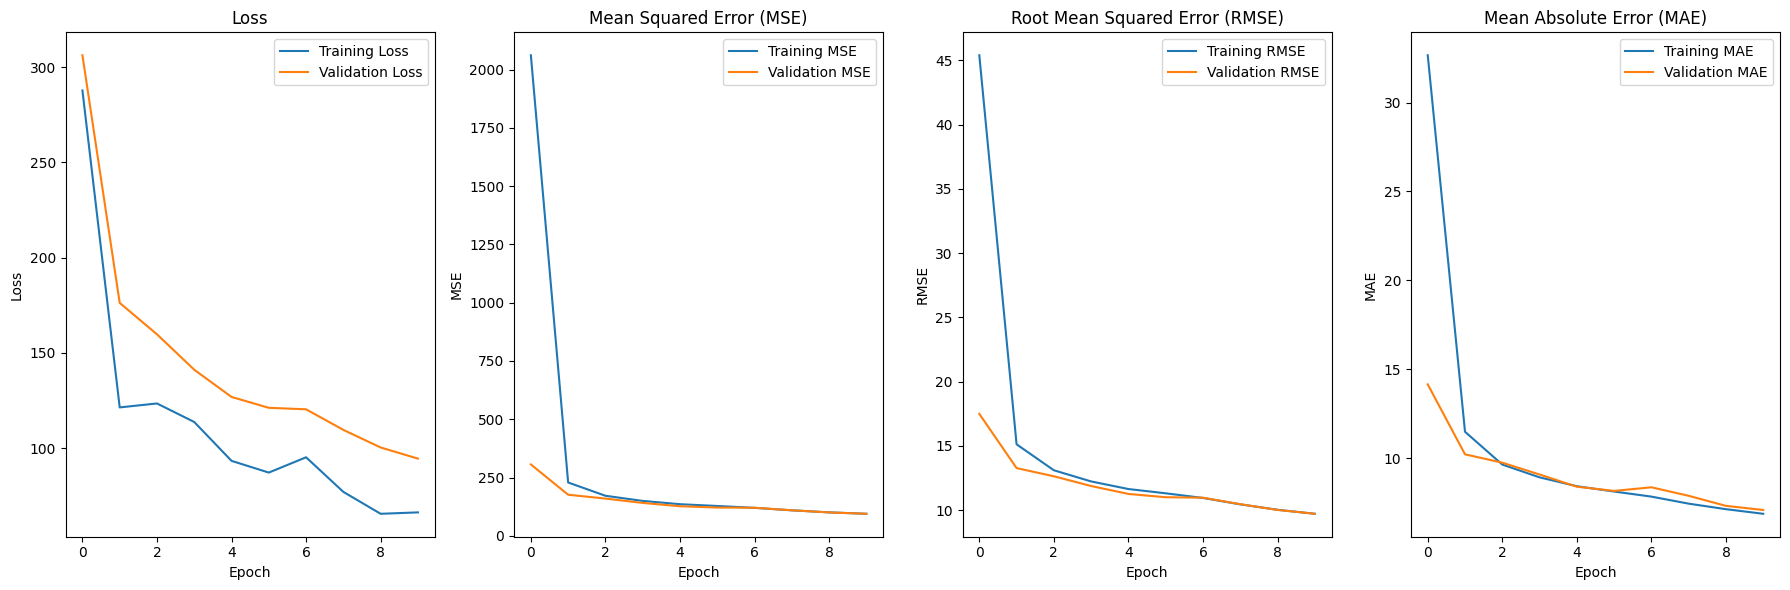

In [38]:
plt.figure(figsize=(18, 6))

# Plot training and validation loss
plt.subplot(1, 4, 1)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation MSE
plt.subplot(1, 4, 2)
plt.plot(history['train_mse'], label='Training MSE')
plt.plot(history['val_mse'], label='Validation MSE')
plt.title('Mean Squared Error (MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

# Plot training and validation RMSE
plt.subplot(1, 4, 3)
plt.plot(history['train_rmse'], label='Training RMSE')
plt.plot(history['val_rmse'], label='Validation RMSE')
plt.title('Root Mean Squared Error (RMSE)')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()

# Plot training and validation MAE
plt.subplot(1, 4, 4)
plt.plot(history['train_mae'], label='Training MAE')
plt.plot(history['val_mae'], label='Validation MAE')
plt.title('Mean Absolute Error (MAE)')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [40]:
rul_pred = model.predict(processed_test_data).reshape(-1)
preds_for_each_engine = np.split(rul_pred, np.cumsum(num_test_windows_list)[:-1])
mean_pred_for_each_engine = [np.average(ruls_for_each_engine, weights = np.repeat(1/num_windows, num_windows)) 
                             for ruls_for_each_engine, num_windows in zip(preds_for_each_engine, num_test_windows_list)]

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


In [42]:
rmse_lstm = np.sqrt(mean_squared_error(true_rul, mean_pred_for_each_engine))
print("RMSE: ", rmse_lstm)

mse_lstm = mean_squared_error(true_rul, mean_pred_for_each_engine)
print("MSE:", mse_lstm)

mae_lstm = mean_absolute_error(true_rul, mean_pred_for_each_engine)
print("MAE:", mae_lstm)

r2_lstm = r2_score(true_rul, mean_pred_for_each_engine)
print("R-squared (R2) Score:", r2_lstm)

%store mse_lstm
%store rmse_lstm
%store mae_lstm
%store r2_lstm

RMSE:  15.632466588221883
MSE: 244.3740116318735
MAE: 11.669816594123843
R-squared (R2) Score: 0.8584872814763352
Stored 'mse_lstm' (float64)
Stored 'rmse_lstm' (float64)
Stored 'mae_lstm' (float64)
Stored 'r2_lstm' (float64)


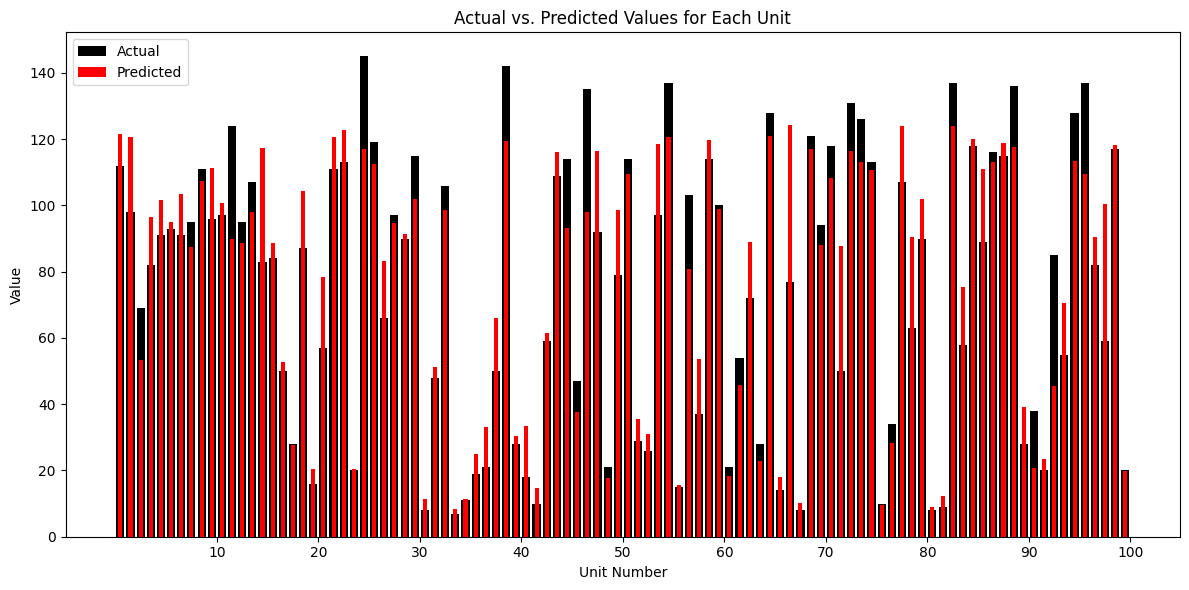

In [43]:
num_units = len(true_rul)
unit_numbers = np.arange(1, num_units + 1) 

actual_values = true_rul
predicted_values = mean_pred_for_each_engine

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.8
spacing = 1

ax.bar(unit_numbers - spacing/2, actual_values, bar_width, label='Actual', color='black')
ax.bar(unit_numbers - spacing/2, predicted_values, bar_width/2, label='Predicted', color='red')

ax.set_xlabel('Unit Number')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for Each Unit')

tick_positions = np.arange(10, num_units + 1, 10)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(int(t)) for t in tick_positions]) 

ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# Define RUL ranges
High_Risk = (0, 20)
Mid_Risk = (21, 50)
Low_Risk = (51, 90)
Healthy = (91, 200)

ranges = [High_Risk, Mid_Risk, Low_Risk, Healthy]
subsets = [{}, {}, {}, {}]

for i, r in enumerate(ranges):
    indices = np.where((FD1_y_Test_array >= r[0]) & (FD1_y_Test_array <= r[1]))[0]
    subsets[i]['RUL'] = FD1_y_Test_array[indices]
    subsets[i]['unit_number'] = indices

# Now subsets[0] contains data for High_Risk range, subsets[1] for Mid_Risk, and so on
subset_1 = subsets[0]
subset_2 = subsets[1]
subset_3 = subsets[2]
subset_4 = subsets[3]

y_Test_subset_1 = subset_1['RUL']
y_Test_subset_2 = subset_2['RUL']
y_Test_subset_3 = subset_3['RUL']
y_Test_subset_4 = subset_4['RUL']

nn_subset1_pred = [mean_pred_for_each_engine[i] for i in subset_1['unit_number']]
nn_subset2_pred = [mean_pred_for_each_engine[i] for i in subset_2['unit_number']]
nn_subset3_pred = [mean_pred_for_each_engine[i] for i in subset_3['unit_number']]
nn_subset4_pred = [mean_pred_for_each_engine[i] for i in subset_4['unit_number']]

# Print the lengths of predictions to verify
print("Predictions for Subset 1 (RUL range [0, ]):", len(nn_subset1_pred))
print("Predictions for Subset 2 (RUL range [, ]):", len(nn_subset2_pred))
print("Predictions for Subset 3 (RUL range [, ]):", len(nn_subset3_pred))
print("Predictions for Subset 4 (RUL range [, 200]):", len(nn_subset4_pred))

Predictions for Subset 1 (RUL range [0, ]): 16
Predictions for Subset 2 (RUL range [, ]): 17
Predictions for Subset 3 (RUL range [, ]): 21
Predictions for Subset 4 (RUL range [, 200]): 46


In [18]:
# Mean Squared Error
mse_test_nn_sub1 = mean_squared_error(y_Test_subset_1, nn_subset1_pred)
mse_test_nn_sub2 = mean_squared_error(y_Test_subset_2, nn_subset2_pred)
mse_test_nn_sub3 = mean_squared_error(y_Test_subset_3, nn_subset3_pred)
mse_test_nn_sub4 = mean_squared_error(y_Test_subset_4, nn_subset4_pred)

# Root Mean Squared Error
rmse_test_nn_sub1 = np.sqrt(mse_test_nn_sub1)
rmse_test_nn_sub2 = np.sqrt(mse_test_nn_sub2)
rmse_test_nn_sub3 = np.sqrt(mse_test_nn_sub3)
rmse_test_nn_sub4 = np.sqrt(mse_test_nn_sub4)

# Mean Absolute Error
mae_test_nn_sub1 = mean_absolute_error(y_Test_subset_1, nn_subset1_pred)
mae_test_nn_sub2 = mean_absolute_error(y_Test_subset_2, nn_subset2_pred)
mae_test_nn_sub3 = mean_absolute_error(y_Test_subset_3, nn_subset3_pred)
mae_test_nn_sub4 = mean_absolute_error(y_Test_subset_4, nn_subset4_pred)

# Testing Set
print("\n--Units at High Risk--")
print("Mean Squared Error:", mse_test_nn_sub1)
print("Root Mean Squared Error:", rmse_test_nn_sub1)
print("Mean Absolute Error:", mae_test_nn_sub1)
print("\n--Units at Mid Risk--")
print("Mean Squared Error:", mse_test_nn_sub2)
print("Root Mean Squared Error:", rmse_test_nn_sub2)
print("Mean Absolute Error:", mae_test_nn_sub2)
print("\n--Units at Low Risk--")
print("Mean Squared Error:", mse_test_nn_sub3)
print("Root Mean Squared Error:", rmse_test_nn_sub3)
print("Mean Absolute Error:", mae_test_nn_sub3)
print("\n--Healthy Units--")
print("Mean Squared Error:", mse_test_nn_sub4)
print("Root Mean Squared Error:", rmse_test_nn_sub4)
print("Mean Absolute Error:", mae_test_nn_sub4)


--Units at High Risk--
Mean Squared Error: 33.88165447066722
Root Mean Squared Error: 5.820795003319325
Mean Absolute Error: 5.183637338876725

--Units at Mid Risk--
Mean Squared Error: 113.39046073547841
Root Mean Squared Error: 10.6484957029375
Mean Absolute Error: 8.383118236766144

--Units at Low Risk--
Mean Squared Error: 609.4744658632876
Root Mean Squared Error: 24.687536650368493
Mean Absolute Error: 22.276495506649933

--Healthy Units--
Mean Squared Error: 196.265284276287
Root Mean Squared Error: 14.009471234714285
Mean Absolute Error: 11.865912445731782


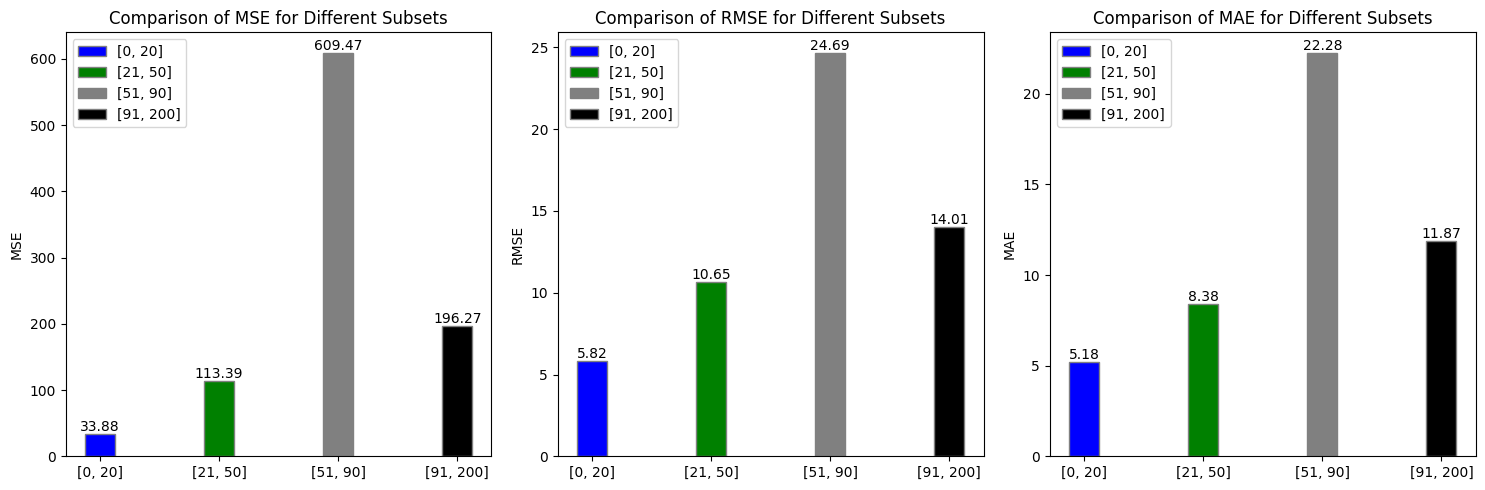

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Define metrics for each subset
mse_values = [mse_test_nn_sub1, mse_test_nn_sub2, mse_test_nn_sub3, mse_test_nn_sub4]
rmse_values = [rmse_test_nn_sub1, rmse_test_nn_sub2, rmse_test_nn_sub3, rmse_test_nn_sub4]
mae_values = [mae_test_nn_sub1, mae_test_nn_sub2, mae_test_nn_sub3, mae_test_nn_sub4]

subset_labels = ['[0, 20]', '[21, 50]', '[51, 90]', '[91, 200]']
bar_width = 0.25

r1 = np.arange(len(subset_labels))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Plot MSE
mse_bars = ax1.bar(r1, mse_values, color=['blue', 'green', 'grey', 'black'], width=bar_width, edgecolor='grey')
for bar in mse_bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height, '%.2f' % height, ha='center', va='bottom')
ax1.set_ylabel('MSE')
ax1.set_title('Comparison of MSE for Different Subsets')
ax1.set_xticks(r1)
ax1.set_xticklabels(subset_labels)

# Plot RMSE
rmse_bars = ax2.bar(r1, rmse_values, color=['blue', 'green', 'grey', 'black'], width=bar_width, edgecolor='grey')
for bar in rmse_bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, height, '%.2f' % height, ha='center', va='bottom')
ax2.set_ylabel('RMSE')
ax2.set_title('Comparison of RMSE for Different Subsets')
ax2.set_xticks(r1)
ax2.set_xticklabels(subset_labels)

# Plot MAE
mae_bars = ax3.bar(r1, mae_values, color=['blue', 'green', 'grey', 'black'], width=bar_width, edgecolor='grey')
for bar in mae_bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width() / 2, height, '%.2f' % height, ha='center', va='bottom')
ax3.set_ylabel('MAE')
ax3.set_title('Comparison of MAE for Different Subsets')
ax3.set_xticks(r1)
ax3.set_xticklabels(subset_labels)

legend_handles = [Patch(facecolor=color, edgecolor='grey', label=label) for color, label in zip(['blue', 'green', 'grey', 'black'], subset_labels)]

ax1.legend(handles=legend_handles, loc='upper left')
ax2.legend(handles=legend_handles, loc='upper left')
ax3.legend(handles=legend_handles, loc='upper left')

plt.tight_layout()
plt.show()


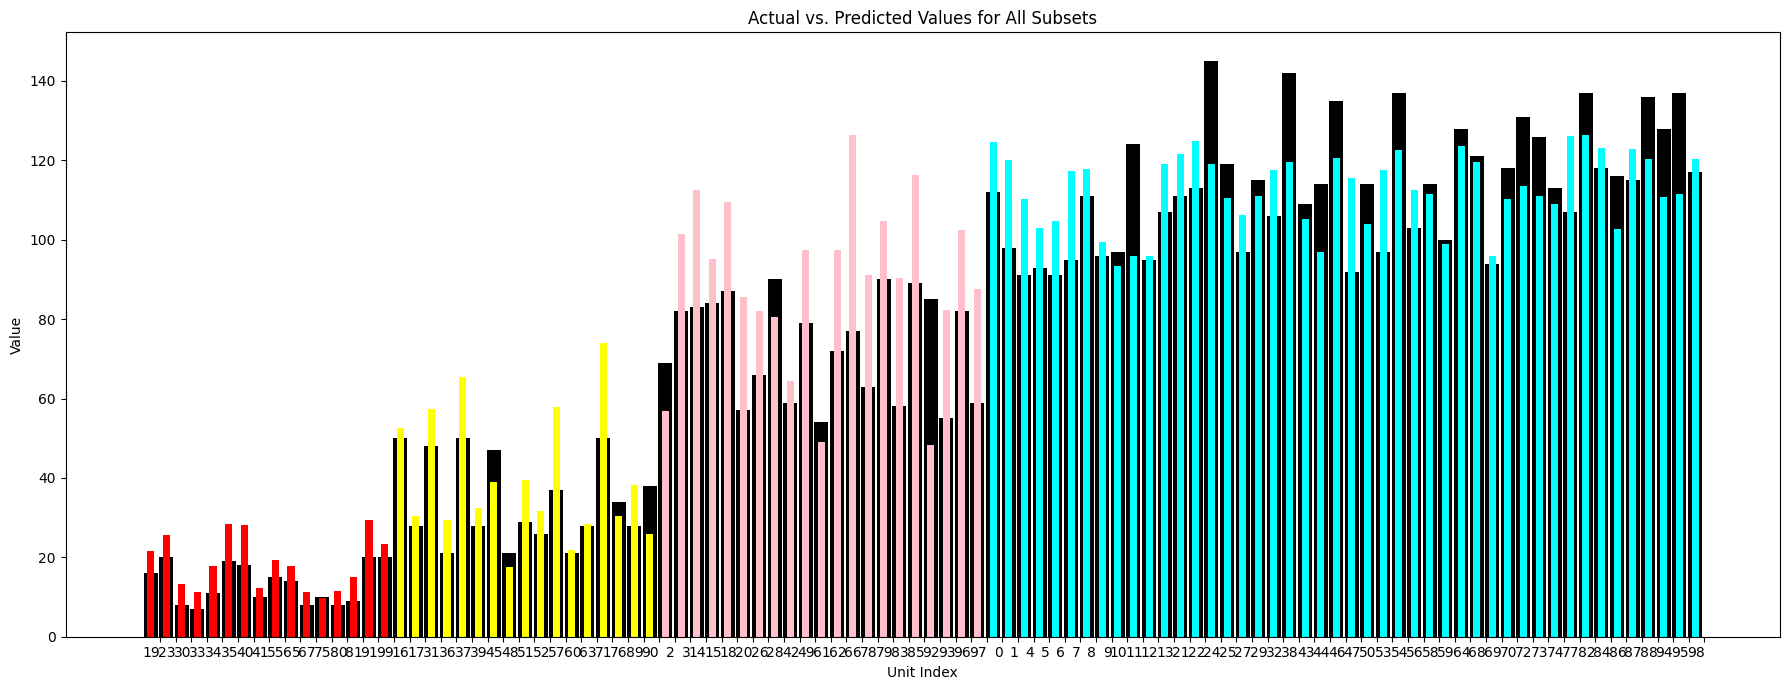

In [20]:
spacing = 1.2
actual_bar_width = 0.9
predicted_bar_width = 0.45

fig, ax = plt.subplots(figsize=(18, 7))

# Plotting for subset 1
subset_1_tick_positions = np.linspace(0, len(subset_1['unit_number']) - 1, num=len(subset_1['unit_number']))
for pos in subset_1_tick_positions:
    ax.bar(pos - spacing/2, subset_1['RUL'][int(pos)], width=actual_bar_width, label='Actual Subset 1', color='black')
    ax.bar(pos - spacing/2, nn_subset1_pred[int(pos)], width=predicted_bar_width, label='Predicted Subset 1', color='red')

# Plotting for subset 2
subset_2_tick_positions = np.linspace(0, len(subset_2['unit_number']) - 1, num=len(subset_2['unit_number']))
for pos in subset_2_tick_positions:
    ax.bar(pos + len(subset_1_tick_positions) - spacing/2, subset_2['RUL'][int(pos)], width=actual_bar_width, label='Actual Subset 2', color='black')
    ax.bar(pos + len(subset_1_tick_positions) - spacing/2, nn_subset2_pred[int(pos)], width=predicted_bar_width, label='Predicted Subset 2', color='yellow')

# Plotting for subset 3
subset_3_tick_positions = np.linspace(0, len(subset_3['unit_number']) - 1, num=len(subset_3['unit_number']))
for pos in subset_3_tick_positions:
    ax.bar(pos + len(subset_1_tick_positions) + len(subset_2_tick_positions) - spacing/2, subset_3['RUL'][int(pos)], width=actual_bar_width, label='Actual Subset 3', color='black')
    ax.bar(pos + len(subset_1_tick_positions) +len(subset_2_tick_positions) - spacing/2, nn_subset3_pred[int(pos)], width=predicted_bar_width, label='Predicted Subset 3', color='pink')

# Plotting for subset 4
subset_4_tick_positions = np.linspace(0, len(subset_4['unit_number']) - 1, num=len(subset_4['unit_number']))
for pos in subset_4_tick_positions:
    ax.bar(pos + len(subset_1_tick_positions) + len(subset_2_tick_positions) + len(subset_3_tick_positions) - spacing/2, subset_4['RUL'][int(pos)], width=actual_bar_width, label='Actual Subset 4', color='black')
    ax.bar(pos + len(subset_1_tick_positions) + len(subset_2_tick_positions) + len(subset_3_tick_positions) - spacing/2, nn_subset4_pred[int(pos)], width=predicted_bar_width, label='Predicted Subset 4', color='cyan')

ax.set_xlabel('Unit Index')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for All Subsets')

# Calculate tick positions for subset 3
subset_3_tick_positions = subset_3_tick_positions + len(subset_1_tick_positions) + len(subset_2_tick_positions)

# Calculate tick positions for subset 4
subset_4_tick_positions = subset_4_tick_positions + len(subset_1_tick_positions) + len(subset_2_tick_positions) + len(subset_3_tick_positions)

all_tick_positions = np.concatenate([subset_1_tick_positions, subset_2_tick_positions + len(subset_1_tick_positions), subset_3_tick_positions, subset_4_tick_positions])
all_tick_labels = np.concatenate([subset_1['unit_number'], subset_2['unit_number'], subset_3['unit_number'], subset_4['unit_number']])
ax.set_xticks(all_tick_positions)
ax.set_xticklabels(all_tick_labels, ha='right')

plt.tight_layout()
plt.show()

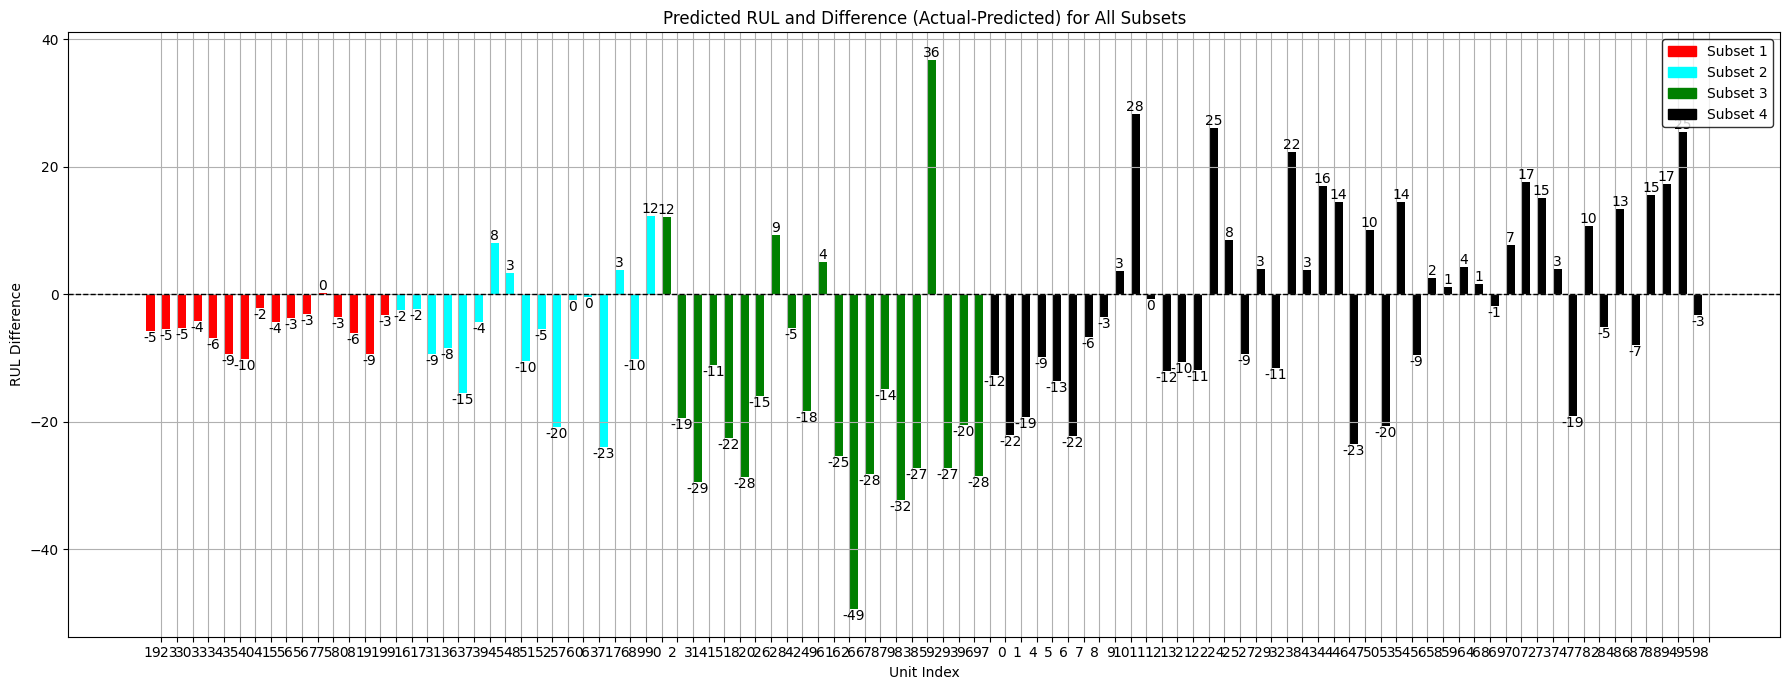

In [21]:
spacing = 1.4
actual_bar_width = 0.55

fig, ax = plt.subplots(figsize=(18, 7))

# Plotting for subset 1
subset_1_tick_positions = np.linspace(0, len(subset_1['unit_number']) - 1, num=len(subset_1['unit_number']))
bars1 = []
diffs1 = []
for pos in subset_1_tick_positions:
    difference1 = subset_1['RUL'][int(pos)] - nn_subset1_pred[int(pos)]
    bars1.append(ax.bar(pos - spacing/2, difference1, width=actual_bar_width, label='Difference (Actual-Predicted)', color='red'))
    diffs1.append(difference1)

# Plotting for subset 2
subset_2_tick_positions = np.linspace(0, len(subset_2['unit_number']) - 1, num=len(subset_2['unit_number']))
bars2 = []
diffs2 = []
for pos in subset_2_tick_positions:
    difference2 = subset_2['RUL'][int(pos)] - nn_subset2_pred[int(pos)]
    bars2.append(ax.bar(pos + len(subset_1_tick_positions) - spacing/2, difference2, width=actual_bar_width, label='Difference (Actual-Predicted)', color='cyan'))
    diffs2.append(difference2)

# Plotting for subset 3
subset_3_tick_positions = np.linspace(0, len(subset_3['unit_number']) - 1, num=len(subset_3['unit_number']))
bars3 = []
diffs3 = []
for pos in subset_3_tick_positions:
    difference3 = subset_3['RUL'][int(pos)] - nn_subset3_pred[int(pos)]
    bars3.append(ax.bar(pos + len(subset_1_tick_positions) + len(subset_2_tick_positions) - spacing/2, difference3, width=actual_bar_width, label='Difference (Actual-Predicted)', color='green'))
    diffs3.append(difference3)

# Plotting for subset 4
subset_4_tick_positions = np.linspace(0, len(subset_4['unit_number']) - 1, num=len(subset_4['unit_number']))
bars4 = []
diffs4 = []
for pos in subset_4_tick_positions:
    difference4 = subset_4['RUL'][int(pos)] - nn_subset4_pred[int(pos)]
    bars4.append(ax.bar(pos + len(subset_1_tick_positions) + len(subset_2_tick_positions) + len(subset_3_tick_positions) - spacing/2, difference4, width=actual_bar_width, label='Difference (Actual-Predicted)', color='black'))
    diffs4.append(difference4)

ax.set_xlabel('Unit Index')
ax.set_ylabel('RUL Difference')
ax.set_title('Predicted RUL and Difference (Actual-Predicted) for All Subsets')

ax.axhline(y=0, color='black', linestyle='--', linewidth=1, label='-')

for bars, diffs in zip([bars1, bars2, bars3, bars4], [diffs1, diffs2, diffs3, diffs4]):
    for bar, diff in zip(bars, diffs):
        for b in bar:
            va = 'top' if diff < 0 else 'bottom'
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f'{int(diff)}', ha='center', va=va)

# Calculate tick positions for subset 3
subset_3_tick_positions = subset_3_tick_positions + len(subset_1_tick_positions) + len(subset_2_tick_positions)

# Calculate tick positions for subset 4
subset_4_tick_positions = subset_4_tick_positions + len(subset_1_tick_positions) + len(subset_2_tick_positions) + len(subset_3_tick_positions)

all_tick_positions = np.concatenate([subset_1_tick_positions, subset_2_tick_positions + len(subset_1_tick_positions), subset_3_tick_positions, subset_4_tick_positions])
all_tick_labels = np.concatenate([subset_1['unit_number'], subset_2['unit_number'], subset_3['unit_number'], subset_4['unit_number']])
ax.set_xticks(all_tick_positions)
ax.set_xticklabels(all_tick_labels, ha='right')

legend_handles = []
legend_labels = ['Subset 1', 'Subset 2', 'Subset 3', 'Subset 4']
colors = ['red', 'cyan', 'green', 'black']

for label, color in zip(legend_labels, colors):
    legend_handles.append(mpatches.Patch(color=color, label=label))

ax.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1, 1), edgecolor='black', facecolor='white')
plt.grid()
plt.tight_layout()
plt.show()